# Processamento de Linguagem Natural

In [7]:
from pathlib import Path

import sklearn.datasets
from dotenv import load_dotenv
import kaggle
import pandas as pd
import seaborn as sb

import nltk
from nltk.corpus import stopwords
from gensim.utils import simple_preprocess
from sklearn.datasets import fetch_20newsgroups

In [8]:
ROOT_DIR = Path().resolve().__str__() + '\\'
DATASET_DIR = 'dataset'

load_dotenv(ROOT_DIR + 'secrets.env')

True

In [9]:
# Download latest version
kaggle.api.authenticate()
Path.mkdir(Path(ROOT_DIR + DATASET_DIR), parents=True, exist_ok=True)
kaggle.api.dataset_download_files('olistbr/brazilian-ecommerce', path=ROOT_DIR + DATASET_DIR, unzip=True)

print("Path to dataset files:", ROOT_DIR + DATASET_DIR)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
Path to dataset files: C:\Users\Renata\DataspellProjects\Infnet-MIT-IA-PLN-PD_26E2_\dataset


In [10]:
reviews = pd.read_csv(ROOT_DIR + DATASET_DIR + '\\olist_order_reviews_dataset.csv')
reviews.dropna(axis=0, subset=['review_comment_message'], inplace=True)
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01
...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43


<Axes: >

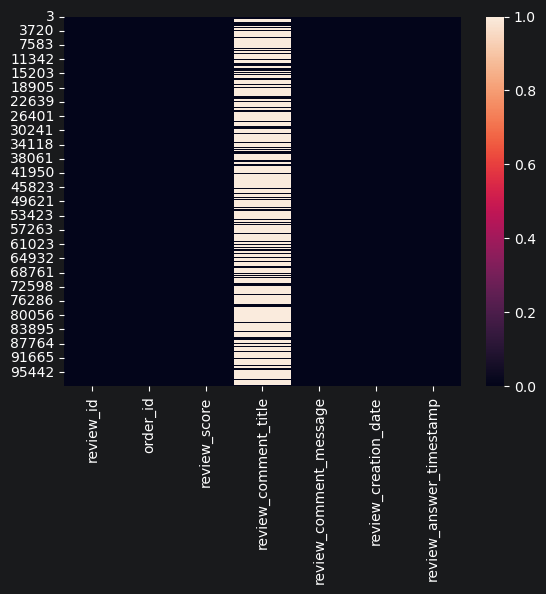

In [11]:
sb.heatmap(reviews.isna())

## Categorias

- 1 = Péssimo
- 2 = Ruim
- 3 = Regular
- 4 = Bom
- 5 = Excelente

In [81]:
import numpy as np

nltk.download('stopwords')

stop_words = stopwords.words('portuguese')
# categories = dict({1: ['Péssimo'], 2: ['Ruim'], 3: ['Regular'], 4: ['Bom'], 5: ['Excelente']})
categories = dict({1: 'Péssimo', 2: 'Ruim', 3: 'Regular', 4: 'Bom', 5: 'Excelente'})
# categories = dict({'Péssimo': '1', 'Ruim': '2', 'Regular': '3', 'Bom': '4', 'Excelente': '5'})
cat = np.array(categories.values())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
def clean_text(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [token for token in tokens if token not in stop_words]

In [21]:
reviews['tokens'] = reviews['review_comment_message'].apply(clean_text)

In [160]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,tokens
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,"[recebi, bem, antes, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,"[parabens, lojas, lannister, adorei, comprar, ..."
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,"[aparelho, eficiente, site, marca, aparelho, i..."
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"[pouco, travando, valor, boa]"
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"[vendedor, confiavel, produto, entrega, antes,..."
...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,"[produto, recebi, acordo, compra, realizada]"
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,"[entregou, dentro, prazo, produto, chegou, con..."
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,"[produto, nao, enviado, nao, existe, venda, ce..."
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,"[excelente, mochila, entrega, super, rapida, s..."


In [107]:
import gensim.corpora as corpora
from gensim.models.ldamodel import LdaModel


categories_clean = clean_text(list(categories.values()).__str__())

id_dict = corpora.Dictionary([categories_clean])

corpus = [id_dict.doc2bow(text) for text in reviews['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=id_dict,
    num_topics=8,
    chunksize=100,
    passes=20,
    per_word_topics=False,
    random_state=42
)

In [157]:
for idx, topic in lda_model.print_topics(-1):
    print(topic)

1.000*"excelente" + 0.000*"bom" + 0.000*"ruim" + 0.000*"pessimo" + 0.000*"regular"
1.000*"bom" + 0.000*"excelente" + 0.000*"ruim" + 0.000*"pessimo" + 0.000*"regular"
0.997*"pessimo" + 0.001*"bom" + 0.001*"ruim" + 0.001*"excelente" + 0.001*"regular"
0.627*"bom" + 0.093*"excelente" + 0.093*"ruim" + 0.093*"pessimo" + 0.093*"regular"
1.000*"bom" + 0.000*"excelente" + 0.000*"ruim" + 0.000*"regular" + 0.000*"pessimo"
0.918*"regular" + 0.021*"bom" + 0.021*"excelente" + 0.021*"ruim" + 0.021*"pessimo"
0.998*"ruim" + 0.001*"bom" + 0.001*"excelente" + 0.001*"pessimo" + 0.001*"regular"
1.000*"bom" + 0.000*"ruim" + 0.000*"excelente" + 0.000*"pessimo" + 0.000*"regular"


In [158]:
import re
def get_token(topic):
    pattern = r"[a-z]+"
    search = re.findall(pattern, topic)
    return search[0] if search is  not None else None

In [159]:
for idx, topic in lda_model.print_topics(-1, 1):
    print(get_token(topic))

excelente
bom
pessimo
bom
bom
regular
ruim
bom
